In [2]:
from google.colab import files
uploaded = files.upload()

print("Uploaded files:")
for k in uploaded.keys():
    print(" -", k)


Saving set_1.class to set_1.class
Saving set_2.class to set_2.class
Uploaded files:
 - set_1.class
 - set_2.class


Using: set_1.class set_2.class
Fold 1: n=286470  pos=184  neg=286286  with_domain=286470
Fold 2: n=287161  pos=184  neg=286977  with_domain=287161


/tmp/ipython-input-690986758.py:155: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(out, dpi=300, bbox_inches="tight")


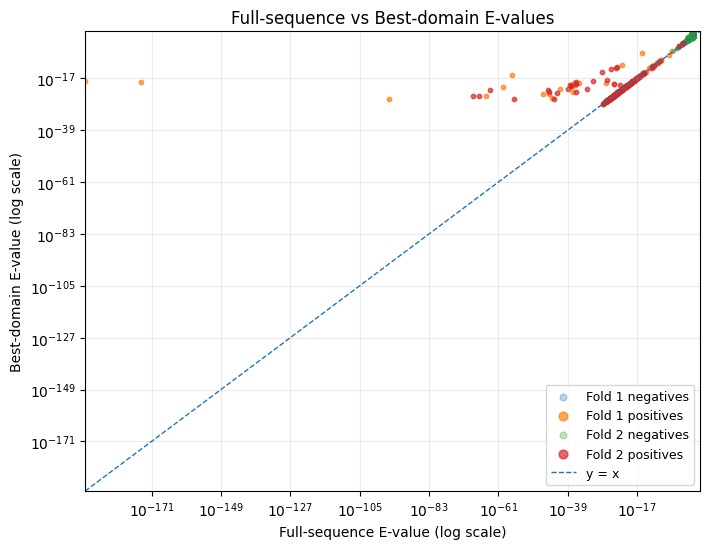

Saved: Figure_fullseq_vs_domain_evalues.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import os, re, math
import numpy as np
import matplotlib.pyplot as plt


def pick_file(prefix="set_1", ext=".class"):
    # pick the best match in current directory
    candidates = [f for f in os.listdir(".") if f.startswith(prefix) and f.endswith(ext)]
    if not candidates:
        raise FileNotFoundError(f"No file found starting with '{prefix}' and ending with '{ext}'. "
                                f"Current dir files: {os.listdir('.')[:20]} ...")
    # prefer exact name if exists
    exact = f"{prefix}{ext}"
    if exact in candidates:
        return exact
    # otherwise pick the shortest (often "set_1 (1).class" etc.)
    return sorted(candidates, key=len)[0]

# Explicit filenames (after upload)
FILE1 = next(k for k in uploaded if k.startswith("set_1") and k.endswith(".class"))
FILE2 = next(k for k in uploaded if k.startswith("set_2") and k.endswith(".class"))

print("Using:", FILE1, FILE2)


# 2) Parse .class file
# Expected columns per line (whitespace):
#   ID  label  full_seq_evalue  best_domain_evalue
# label: 1 positive, 0 negative
# Lines starting with '#' are ignored.

def parse_class_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            seq_id = parts[0]
            try:
                label = int(parts[1])
            except:
                continue

            # full-seq is column 3 (index 2)
            try:
                full_e = float(parts[2])
            except:
                continue

            # best-domain often column 4 (index 3)
            dom_e = None
            if len(parts) >= 4:
                try:
                    dom_e = float(parts[3])
                except:
                    dom_e = None

            rows.append((seq_id, label, full_e, dom_e))
    return rows

data1 = parse_class_file(FILE1)
data2 = parse_class_file(FILE2)

def summarize(data, name):
    n = len(data)
    pos = sum(1 for _,y,_,__ in data if y==1)
    neg = sum(1 for _,y,_,__ in data if y==0)
    have_dom = sum(1 for *_, dom in data if dom is not None)
    print(f"{name}: n={n}  pos={pos}  neg={neg}  with_domain={have_dom}")

summarize(data1, "Fold 1")
summarize(data2, "Fold 2")

# 3) Build arrays

def to_xy(data):
    x_full = []
    y_dom  = []
    labels = []
    ids    = []
    for sid, y, full_e, dom_e in data:
        if dom_e is None:
            continue
        x_full.append(full_e)
        y_dom.append(dom_e)
        labels.append(y)
        ids.append(sid)
    return np.array(x_full), np.array(y_dom), np.array(labels), ids

x1, y1, lab1, ids1 = to_xy(data1)
x2, y2, lab2, ids2 = to_xy(data2)

if len(x1)==0 or len(x2)==0:
    raise ValueError(
        "Your .class files do not seem to contain the best-domain E-value column.\n"
        "They must have: ID label full_seq_evalue best_domain_evalue.\n"
        "If you only have one E-value, tell me and I’ll adapt the plot."
    )

# Replace zeros to avoid log issues
EPS = 1e-300
x1 = np.maximum(x1, EPS); y1 = np.maximum(y1, EPS)
x2 = np.maximum(x2, EPS); y2 = np.maximum(y2, EPS)


# Plot

def scatter_fold(ax, x, y, labels, title):
    pos = labels == 1
    neg = labels == 0
    ax.scatter(x[neg], y[neg], s=6, alpha=0.30, label=f"{title} negatives")
    ax.scatter(x[pos], y[pos], s=10, alpha=0.70, label=f"{title} positives")

# Determine axis limits
allx = np.concatenate([x1, x2])
ally = np.concatenate([y1, y2])
xmin, xmax = np.min(allx), np.max(allx)
ymin, ymax = np.min(ally), np.max(ally)
lo = min(xmin, ymin)
hi = max(xmax, ymax)

fig, ax = plt.subplots(figsize=(7.2, 5.6))

scatter_fold(ax, x1, y1, lab1, "Fold 1")
scatter_fold(ax, x2, y2, lab2, "Fold 2")

ax.set_xscale("log")
ax.set_yscale("log")

# y = x diagonal
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, label="y = x")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

ax.set_xlabel("Full-sequence E-value (log scale)")
ax.set_ylabel("Best-domain E-value (log scale)")
ax.set_title("Full-sequence vs Best-domain E-values")

ax.grid(True, which="both", alpha=0.25)
ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
out = "Figure_fullseq_vs_domain_evalues.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out)
files.download("Figure_fullseq_vs_domain_evalues.png")